## 랜덤 포레스트

### 1. 전처리 및 피쳐 생성

In [ ]:
import pandas as pd
import numpy as np

In [7]:
# 1. src 폴더 내의 모듈에서 함수 임포트
from src.seed import set_seed
from src.pipeline.missing_value import JH_train_stats, JH_MissingValue, CJ_MissingValue
from src.pipeline.outlier_control import OutlierControl
from src.pipeline.features import FeatureCreate

In [10]:
# 2. 데이터 로드 및 시드 고정
set_seed(42)
df_raw = pd.read_excel('data/dataset.xlsx')

In [15]:
# 1단계: 결측치 처리 (원본 df_raw 기준) - JH_MissingValue
stats = JH_train_stats(df_raw)
df_filled = JH_MissingValue(df_raw.copy(), **stats)

In [27]:
# 1단계: 결측치 처리 (원본 df_raw 기준) - CJ_MissingValue
df_filled = CJ_MissingValue(df_filled, 'Tenure', 'PreferedOrderCat', 5, df_raw['Tenure'].median())
df_filled = CJ_MissingValue(df_filled, 'OrderAmountHikeFromlastYear', 'CityTier', 5, df_raw['OrderAmountHikeFromlastYear'].median())
df_filled = CJ_MissingValue(df_filled, 'OrderCount', 'PreferedOrderCat', 5, df_raw['OrderCount'].median())
df_filled = CJ_MissingValue(df_filled, 'DaySinceLastOrder', 'PreferedOrderCat', 5, df_raw['DaySinceLastOrder'].median())

In [28]:
# 1단계: 결측치 처리 (원본 df_raw 기준) - 결과 확인
print("JH 및 CJ 결측치 처리 완료")
print(df_filled.isnull().sum()) # 결측치가 모두 0인지 확인

JH 및 CJ 결측치 처리 완료
CustomerID                     0
Churn                          0
Tenure                         0
PreferredLoginDevice           0
CityTier                       0
WarehouseToHome                0
PreferredPaymentMode           0
Gender                         0
HourSpendOnApp                 0
NumberOfDeviceRegistered       0
PreferedOrderCat               0
SatisfactionScore              0
MaritalStatus                  0
NumberOfAddress                0
Complain                       0
OrderAmountHikeFromlastYear    0
CouponUsed                     0
OrderCount                     0
DaySinceLastOrder              0
CashbackAmount                 0
dtype: int64


In [29]:
# 2단계: 이상치 처리 (Outlier Control) (치환 대상 컬럼 확인 필요)
outlier_cols = ['CashbackAmount', 'DaySinceLastOrder', 'Tenure', 'WarehouseToHome']
df_outlier = OutlierControl(df_filled, outlier_cols)

print("피처 생성 전 결측치 체크:\n", df_outlier.isnull().sum().sum())

피처 생성 전 결측치 체크:
 0


In [30]:
# 3단계: 피처 생성 (Feature Engineering) (여기서 df_final이 정의)
df_final = FeatureCreate(df_outlier)

In [31]:
# 최종 확인
print("최종 데이터셋 결측치 확인:")
print(df_final.isnull().sum())

최종 데이터셋 결측치 확인:
CustomerID                             0
Churn                                  0
CityTier                               0
NumberOfDeviceRegistered               0
NumberOfAddress                        0
OrderAmountHikeFromlastYear            0
Tenure_log                             0
Dormancy_Shock                         0
Recency_Tenure_Ratio                   0
MonthlyOrderFreq                       0
IssueIndex                             0
Satisfaction_Per_Order                 0
Silent_Killer                          0
CashbackPerOrder                       0
Promo_Sensitivity                      0
Stagnant_Loyal                         0
ManyAddressesFlag                      0
PreferredLoginDevice_Mobile Phone      0
PreferredLoginDevice_Phone             0
PreferedOrderCat_Grocery               0
PreferedOrderCat_Laptop & Accessory    0
PreferedOrderCat_Mobile                0
PreferedOrderCat_Mobile Phone          0
PreferedOrderCat_Others                0


In [32]:
# 확인: 컬럼들이 잘 생성되었는지 상위 5개 행 출력
df_final.head()

,CustomerID,Churn,CityTier,NumberOfDeviceRegistered,NumberOfAddress,OrderAmountHikeFromlastYear,Tenure_log,Dormancy_Shock,Recency_Tenure_Ratio,MonthlyOrderFreq,...,PreferredLoginDevice_Mobile Phone,PreferredLoginDevice_Phone,PreferedOrderCat_Grocery,PreferedOrderCat_Laptop & Accessory,PreferedOrderCat_Mobile,PreferedOrderCat_Mobile Phone,PreferedOrderCat_Others,MaritalStatus_Married,MaritalStatus_Single,Gender_Male
0,50001,1,3,3,9,11.0,1.609438,1.666667,1.25,0.25,...,1,0,0,1,0,0,0,0,1,0
1,50002,1,1,4,7,15.0,1.609438,0.000000,0.00,0.25,...,0,1,0,0,1,0,0,0,1,1
2,50003,1,1,4,6,14.0,1.609438,1.000000,0.75,0.25,...,0,1,0,0,1,0,0,0,1,1
3,50004,1,3,4,8,23.0,0.000000,2.727273,30.00,10.00,...,0,1,0,1,0,0,0,0,1,1
4,50005,1,1,3,3,11.0,0.000000,2.727273,30.00,10.00,...,0,1,0,0,1,0,0,0,1,1


In [33]:
print(df_final.isnull().sum()) # 결측치가 모두 0인지 확인

CustomerID                             0
Churn                                  0
CityTier                               0
NumberOfDeviceRegistered               0
NumberOfAddress                        0
OrderAmountHikeFromlastYear            0
Tenure_log                             0
Dormancy_Shock                         0
Recency_Tenure_Ratio                   0
MonthlyOrderFreq                       0
IssueIndex                             0
Satisfaction_Per_Order                 0
Silent_Killer                          0
CashbackPerOrder                       0
Promo_Sensitivity                      0
Stagnant_Loyal                         0
ManyAddressesFlag                      0
PreferredLoginDevice_Mobile Phone      0
PreferredLoginDevice_Phone             0
PreferedOrderCat_Grocery               0
PreferedOrderCat_Laptop & Accessory    0
PreferedOrderCat_Mobile                0
PreferedOrderCat_Mobile Phone          0
PreferedOrderCat_Others                0
MaritalStatus_Ma

### 2. 모델 학습

- 데이터 분리 (train/test)

In [34]:
from sklearn.model_selection import train_test_split

In [ ]:
# 학습에 사용할 피처(X)와 타겟(y) 분리
# CustomerID는 예측에 도움이 안 되므로 drop, Churn은 정답이므로 drop
X = df_final.drop(['CustomerID', 'Churn'], axis=1, errors='ignore')
y = df_final['Churn']

In [36]:
# 학습/테스트 데이터 분할 (8:2 비율, 이탈률 불균형을 고려한 stratify 적용)
# stratify=y를 넣어야 이탈자(1)와 비이탈자(0)의 비율이 일정하게 유지

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"학습 데이터 크기: {X_train.shape}")
print(f"테스트 데이터 크기: {X_test.shape}")

학습 데이터 크기: (4504, 25)
테스트 데이터 크기: (1126, 25)


- 모델 생성 및 학습

In [37]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score, roc_auc_score

In [38]:
# 모델 정의
# n_estimators: 나무의 개수 (보통 100~200개)
# max_depth: 나무의 깊이 (과적합 방지를 위해 10~15 정도로 제한)
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    class_weight='balanced', 
    random_state=42
)

# # 과적합 방지를 위해 max_depth를 설정하고, 불균형 데이터 처리를 위해 class_weight 적용
# rf_clf = RandomForestClassifier(
#     n_estimators=200,
#     max_depth=12,
#     min_samples_leaf=5,
#     class_weight='balanced',
#     random_state=42,
#     n_jobs=-1
# )

In [39]:
# 모델 학습
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [40]:
# 예측 수행
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

print("--- 모델 학습 및 예측 완료 ---")

--- 모델 학습 및 예측 완료 ---


- 모델 평가

In [41]:
print(f"최종 F1-Score: {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")
print("\n[상세 평가 지표]")
print(classification_report(y_test, y_pred))

최종 F1-Score: 0.8763
ROC-AUC Score: 0.9888

[상세 평가 지표]
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       936
           1       0.90      0.86      0.88       190

    accuracy                           0.96      1126
   macro avg       0.93      0.92      0.93      1126
weighted avg       0.96      0.96      0.96      1126



### 3. 피쳐 기여도 확인 

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

In [43]:
# 특성 중요도 추출
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
top_15_importances = importances.sort_values(ascending=False).head(15)

C:\Users\Playdata\AppData\Local\Temp\ipykernel_23164\1587662066.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_15_importances, y=top_15_importances.index, palette='viridis')


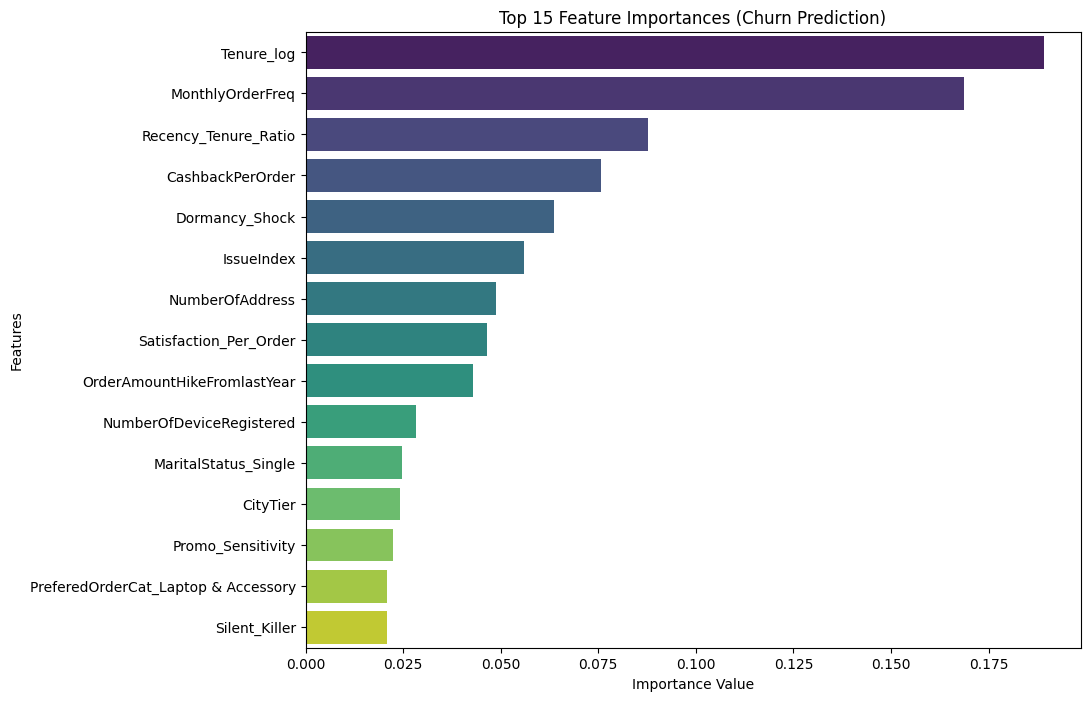

In [44]:
# 시각화
plt.figure(figsize=(10, 8))
sns.barplot(x=top_15_importances, y=top_15_importances.index, palette='viridis')
plt.title('Top 15 Feature Importances (Churn Prediction)')
plt.xlabel('Importance Value')
plt.ylabel('Features')
plt.show()

### 4. 결과 해석
- Tenure (가입 기간), Login & Frequency (접속 빈도) 가 중요한 변수인듯 
    - Tenure_log (가입 기간): 우리랑 얼마나 오래 알고 지냈나?
    - MonthlyOrderFreq (월평균 주문 빈도): 평소에 얼마나 자주 샀나?
    - Recency_Tenure_Ratio (가입 기간 대비 최근 미접속 비율): 찐팬이었는데 갑자기 접속이 뜸해졌나?
    - CashbackPerOrder (주문당 캐시백 금액): 캐시백 받는 재미로 쇼핑하나?
    - Dormancy_Shock (휴면 충격 지수): 평소 패턴보다 갑자기 너무 오래 안 왔나?

- 체리피커: "혜택(쿠폰, 캐시백)은 다 챙기면서, 정작 물건은 잘 안 사고 금방 떠날 사람"
    - Tenure_log + CashbackPerOrder = 가입기간은 짧은데 받은 캐시백은 높은 사람
    - MonthlyOrderFreq + Recency_Tenure_Ratio: 평소주문 빈도는 거의 0이지만, 특정 기간에만 접속과 주문이 확 늘어나는 사람
    - CashbackPerOrder + Promo_Sensitivity: 혜택에 대한 민감도


### 4. 학습 vs 검증 점수 차이

In [45]:
from sklearn.metrics import roc_auc_score

# 1. 학습 데이터로 예측 점수 계산
train_prob = rf_model.predict_proba(X_train)[:, 1]
train_auc = roc_auc_score(y_train, train_prob)

In [46]:
# 2. 테스트 데이터로 예측 점수 계산
test_prob = rf_model.predict_proba(X_test)[:, 1]
test_auc = roc_auc_score(y_test, test_prob)

In [ ]:
print(f"학습(Train) AUC 점수: {train_auc:.4f}")
print(f"검증(Test) AUC 점수: {test_auc:.4f}")
print(f"점수 차이(Gap): {abs(train_auc - test_auc):.4f}")

# 점수 차이가 0.05(5점) 이내라면 안정적인 모델

학습(Train) AUC 점수: 0.9998
검증(Test) AUC 점수: 0.9888
점수 차이(Gap): 0.0110


### 5. 교차 검증 (Cross Validation)

In [48]:
from sklearn.model_selection import cross_val_score

In [50]:
# cv=5: 데이터를 5개로 나눔 (5-Fold)
scores = cross_val_score(rf_model, X, y, cv=5, scoring='roc_auc')

In [ ]:
print("--- 5-Fold 교차 검증 결과 ---")
print(f"각 회차별 AUC 점수: {scores}")
print(f"평균 AUC 점수: {np.mean(scores):.4f}")
print(f"점수 표준편차: {np.std(scores):.4f}")

# 표준편차가 매우 작고 평균이 0.9를 넘는다면, 데이터 누수가 없다면 좋은 성능 모델

--- 5-Fold 교차 검증 결과 ---
각 회차별 AUC 점수: [0.99667679 0.99525416 0.99022155 0.99303756 0.99085791]
평균 AUC 점수: 0.9932
점수 표준편차: 0.0025
